In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [5]:
## Step 1: Load and Preprocess Data
# Define transformations for images
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])

In [6]:
# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)

In [7]:
# Get the shape of the first image in the training dataset
image, label = train_dataset[0]
print("Image shape:", image.shape)
print("Number of training samples:", len(train_dataset))

Image shape: torch.Size([1, 28, 28])
Number of training samples: 60000


In [8]:
# Get the shape of the first image in the test dataset
image, label = test_dataset[0]
print("Image shape:", image.shape)
print("Number of testing samples:", len(test_dataset))

Image shape: torch.Size([1, 28, 28])
Number of testing samples: 10000


In [9]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [10]:
import torch.nn.functional as F

class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 6, 3, 1)
        self.conv2 = nn.Conv2d(6, 16, 3, 1)

        # Fully connected layers
        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):

        # Convolution + ReLU + Pool
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        # Flatten
        x = x.view(-1, 5*5*16)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        # Output
        x = F.log_softmax(x, dim=1)

        return x

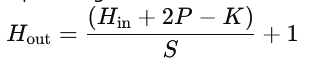

In [11]:
from torchsummary import summary

# Initialize model
model = CNNClassifier()

# Move model to GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)

# Print model summary
print('Name:        ')
print('Register Number:       ')
summary(model, input_size=(1, 28, 28))

Name:        
Register Number:       
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 26, 26]              60
            Conv2d-2           [-1, 16, 11, 11]             880
            Linear-3                  [-1, 120]          48,120
            Linear-4                   [-1, 84]          10,164
            Linear-5                   [-1, 10]             850
Total params: 60,074
Trainable params: 60,074
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.23
Estimated Total Size (MB): 0.28
----------------------------------------------------------------


In [12]:
# Initialize model, loss function, and optimizer
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [13]:
## Step 3: Train the Model
import time
start_time = time.time()

# Variables ( Trackers)
epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

# for loop epochs 
for i in range(epochs):
    
    trn_corr = 0
    tst_corr = 0


    # Run the training batches
    for b, (X_train, y_train) in enumerate(train_loader):
        b+=1
        
        # Apply the model
        y_pred = model(X_train)  # we not flatten X-train here
        loss = criterion(y_pred, y_train)
 
        
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()  # Trure 1 / False 0 sum()
        trn_corr += batch_corr
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print interim results
        if b%600 == 0:
            print(f'epoch: {i}  batch: {b} loss: {loss.item()}')
        
    train_losses.append(loss)
    train_correct.append(trn_corr)
        
    # Run the testing batches
    with torch.no_grad():
        for b, (X_test, y_test) in enumerate(test_loader):

            # Apply the model
            y_val = model(X_test)

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test).sum()
            
    loss = criterion(y_val, y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)
        
current_time = time.time()
total = current_time - start_time
print(f'Training took {total/60} minutes')

epoch: 0  batch: 600 loss: 0.1342533379793167
epoch: 0  batch: 1200 loss: 0.08151005208492279
epoch: 0  batch: 1800 loss: 0.2386864423751831
epoch: 1  batch: 600 loss: 0.03737589344382286
epoch: 1  batch: 1200 loss: 0.0070374105125665665
epoch: 1  batch: 1800 loss: 0.000956509611569345
epoch: 2  batch: 600 loss: 0.01982022076845169
epoch: 2  batch: 1200 loss: 0.014950373210012913
epoch: 2  batch: 1800 loss: 0.00474927481263876
epoch: 3  batch: 600 loss: 0.06253501772880554
epoch: 3  batch: 1200 loss: 0.004458497744053602
epoch: 3  batch: 1800 loss: 0.012423230335116386
epoch: 4  batch: 600 loss: 0.007181180641055107
epoch: 4  batch: 1200 loss: 0.012792863883078098
epoch: 4  batch: 1800 loss: 0.0028161690570414066
Training took 4.72503129641215 minutes


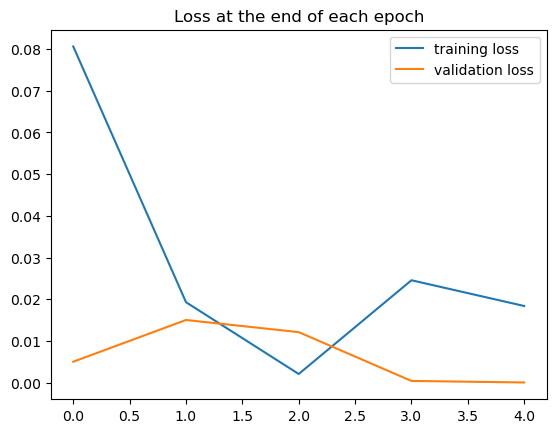

In [15]:
train_losses = [t.detach().numpy() for t in train_losses]
test_losses = [t.detach().numpy() for t in test_losses]

plt.plot(train_losses, label='training loss')
plt.plot(test_losses, label='validation loss')
plt.title('Loss at the end of each epoch')
plt.legend();
plt.show()

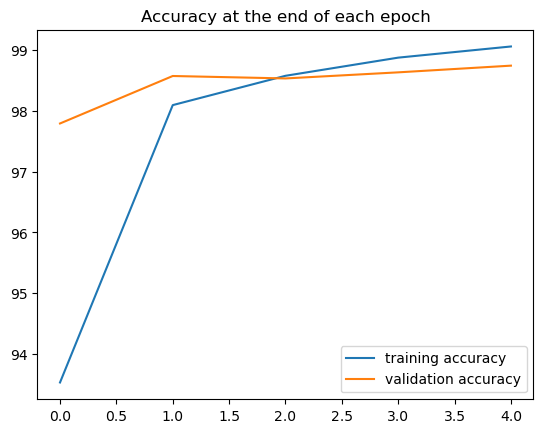

In [16]:
plt.plot([t/600 for t in train_correct], label='training accuracy')
plt.plot([t/100 for t in test_correct], label='validation accuracy')
plt.title('Accuracy at the end of each epoch')
plt.legend();
plt.show()

In [17]:
# Extract the data all at once, not in batches
test_load_all = DataLoader(test_dataset, batch_size=10000, shuffle=False)

In [18]:
with torch.no_grad():
    correct = 0
    for X_test, y_test in test_load_all:
        y_val = model(X_test)  # we don't flatten the data this time
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()

In [19]:
correct.item()

9874

In [20]:
correct.item()/len(test_dataset)

0.9874

In [21]:
# print a row of values for reference
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}'))
print(np.arange(10).reshape(1,10))
print()

# print the confusion matrix
print(confusion_matrix(predicted.view(-1), y_test.view(-1)))

[[   0    1    2    3    4    5    6    7    8    9]]

[[ 969    0    0    0    1    0    3    0    0    0]
 [   0 1130    1    0    0    0    2    3    0    2]
 [   0    0 1018    0    0    1    0    4    1    0]
 [   1    3    3 1007    0   10    1    3    0    1]
 [   1    0    1    0  960    0    3    0    0    2]
 [   1    0    0    0    0  880    3    0    1    3]
 [   2    0    0    0    1    1  935    0    0    0]
 [   0    0    3    0    0    0    0 1010    0    0]
 [   6    2    6    3    5    0   11    2  969    5]
 [   0    0    0    0   15    0    0    6    3  996]]


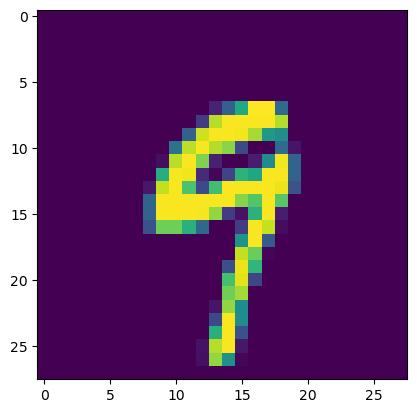

In [22]:
# single image for test 
plt.imshow(test_dataset[2019][0].reshape(28,28))
plt.show()

In [23]:
model.eval()
with torch.no_grad():
    new_prediction = model(test_dataset[2019][0].view(1,1,28,28))

In [24]:
new_prediction.argmax()

tensor(9)

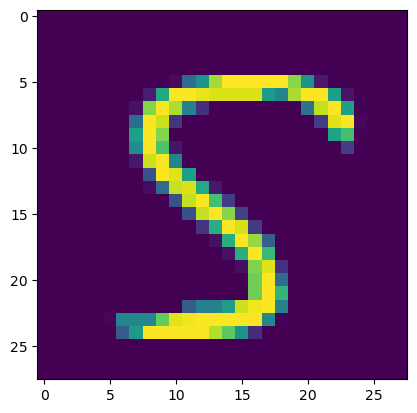

In [25]:
# single image for test 
plt.imshow(test_dataset[333][0].reshape(28,28))
plt.show()

In [26]:
model.eval()
with torch.no_grad():
    new_prediction = model(test_dataset[333][0].view(1,1,28,28))

In [27]:
new_prediction.argmax()

tensor(5)

In [28]:
test_dataset[333][1]

5